In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, rankdata
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import os

In [2]:
print('Chargement des données...')
x_train = pd.read_csv("../data/x_train_final_asAbTs5.csv", index_col=0)
y_train = pd.read_csv('../data/y_train_final_YYyFil7.csv', index_col=0)
x_test  = pd.read_csv('../data/x_test_final_fIrnA7Q.csv',  index_col=0)

print(f'x_train : {x_train.shape}  |  y_train : {y_train.shape}')
print(f'x_test  : {x_test.shape}')

Chargement des données...
x_train : (6076546, 10)  |  y_train : (6076546, 1)
x_test  : (2028750, 10)


In [3]:
x_train

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,3,4,8
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,4,2,16
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,3,9,18
...,...,...,...,...,...,...,...,...,...,...
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,5,7,18
6076542,55,0.998655,0.996093,0.0,0.0,17.0,6.0,6,12,10
6076543,9,0.999200,0.996001,0.0,0.0,11.5,5.1,3,5,12
6076544,14,0.998374,0.996076,0.0,0.0,13.6,3.5,4,11,7


In [ ]:
from sklearn.cluster import KMeans
coords = x_train[['longitude_scaled','latitude_scaled']]
kmeans = KMeans(n_clusters=3, random_state=42)
x_train['geo_cluster'] = kmeans.fit_predict(coords)
x_train

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush,is_week_end,geo_cluster
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,3,4,8,1,0,2
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13,0,1,0
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8,1,0,2
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,4,2,16,0,0,0
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,3,9,18,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,5,7,18,0,1,2
6076542,55,0.998655,0.996093,0.0,0.0,17.0,6.0,6,12,10,0,1,2
6076543,9,0.999200,0.996001,0.0,0.0,11.5,5.1,3,5,12,0,0,0
6076544,14,0.998374,0.996076,0.0,0.0,13.6,3.5,4,11,7,0,0,2


In [70]:
x_train[x_train['latitude_scaled'] <0.99]

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush,is_week_end,geo_cluster,dist_to_center
16359,2,0.980778,2.039470e-07,0.4,0.0,9.6,3.1,2,9,10,0,0,1,0.996278
31566,2,0.980778,2.039470e-07,1.0,0.0,20.1,2.1,1,2,15,0,0,1,0.996278
37122,21,0.980778,2.039470e-07,0.0,0.0,12.4,2.8,4,10,11,0,0,1,0.996278
40463,1,0.980778,0.000000e+00,0.0,0.0,24.5,3.5,2,1,12,0,0,1,0.996278
44401,1,0.980778,2.039470e-07,0.0,0.0,18.4,3.6,2,1,13,0,0,1,0.996278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6037035,4,0.980778,2.039470e-07,0.0,0.0,7.6,4.9,2,6,11,0,0,1,0.996278
6057257,41,0.980778,2.039470e-07,0.0,0.0,16.4,3.9,4,2,7,0,0,1,0.996278
6058224,1,0.980778,2.039470e-07,0.0,0.0,19.0,3.4,3,1,8,1,0,1,0.996278
6065802,1,0.980778,2.039470e-07,0.6,0.0,5.0,3.6,6,8,18,0,1,1,0.996278


In [63]:
x_train["geo_cluster"].value_counts()

geo_cluster
2    3567610
0    2508538
1        398
Name: count, dtype: int64

In [66]:
import numpy as np

center = [x_train['latitude_scaled'].mean(), x_train['longitude_scaled'].mean()]
x_train['dist_to_center'] = np.sqrt(
    (x_train['latitude_scaled'] - center[0])**2 +
    (x_train['longitude_scaled'] - center[1])**2
)

x_train

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush,is_week_end,geo_cluster,dist_to_center
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,3,4,8,1,0,2,0.000436
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13,0,1,0,0.000386
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8,1,0,2,0.000520
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,4,2,16,0,0,0,0.000234
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,3,9,18,0,0,0,0.000408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,5,7,18,0,1,2,0.000456
6076542,55,0.998655,0.996093,0.0,0.0,17.0,6.0,6,12,10,0,1,2,0.000199
6076543,9,0.999200,0.996001,0.0,0.0,11.5,5.1,3,5,12,0,0,0,0.000364
6076544,14,0.998374,0.996076,0.0,0.0,13.6,3.5,4,11,7,0,0,2,0.000481


In [5]:
x_train["hour"].value_counts()

hour
9     598697
14    596622
8     594690
10    584009
11    565575
13    560183
15    550682
16    510814
12    491668
17    488246
7     329269
18    203597
19      1969
6        525
Name: count, dtype: int64

In [ ]:
print(x_train[x_train["HauteurNeige"]>0]["Temperature"].max())
x_train[x_train["HauteurNeige"]>0]
# La hauteur neige > 0 lorsque la temperature est en dessous de 2.7 degré

2.7


,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush,is_week_end,geo_cluster,dist_to_center
5,1,0.999129,0.996507,0.0,1.0,1.5,3.7,4,7,11,0,0,0,0.000480
393,1,0.998955,0.996489,0.0,1.0,2.2,3.6,4,7,16,0,0,0,0.000388
704,6,0.998431,0.996132,0.0,1.0,-0.1,3.9,4,7,9,1,0,2,0.000423
875,12,0.998493,0.995975,0.0,1.0,1.9,3.8,4,7,17,0,0,2,0.000387
1426,1,0.998715,0.995980,0.0,1.0,-1.9,3.4,2,7,12,0,0,2,0.000193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6076041,22,0.998904,0.995714,0.0,1.0,-0.1,3.9,4,7,9,1,0,2,0.000404
6076125,9,0.999287,0.996229,0.0,1.0,2.2,3.6,4,7,16,0,0,0,0.000449
6076147,7,0.998898,0.996153,0.0,1.0,-1.6,3.2,2,7,11,0,0,2,0.000059
6076238,11,0.998737,0.995745,0.0,1.0,-1.9,3.4,2,7,12,0,0,2,0.000387


In [ ]:
x_train.sort_values(by=["total_count"] , ascending=False).head(50)[x_train["dist_to_center"] > 0.0005]

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush,is_week_end,geo_cluster,dist_to_center
2081505,1669,0.999415,0.996149,0.0,0.0,18.0,0.9,6,4,10,0,1,0,0.000562
424115,1100,0.998220,0.995759,0.0,0.0,18.6,1.9,1,1,8,1,0,2,0.000726
869690,1092,0.999410,0.995996,0.0,0.0,16.8,3.5,5,11,13,0,1,0,0.000569
3600430,848,0.999368,0.996642,0.0,0.0,25.9,3.2,5,2,14,0,1,0,0.000738
5364542,813,0.999515,0.996100,0.0,0.0,17.1,2.4,5,10,9,1,1,0,0.000662
4719353,775,0.999359,0.995950,0.0,0.0,17.4,5.5,5,11,15,0,1,0,0.000532
3860222,705,0.999366,0.996041,0.0,0.0,16.0,3.3,5,11,14,0,1,0,0.000518
1250156,705,0.999431,0.995992,0.0,0.0,12.7,5.6,3,9,15,0,0,0,0.000591
2152556,664,0.999287,0.995855,0.0,0.0,12.6,1.5,1,11,8,1,0,0,0.000505
2673368,637,0.999430,0.995996,0.0,0.0,-0.3,4.6,1,7,15,0,0,0,0.000588


In [ ]:
x_train[x_train["dist_to_center"] > 0.0005]["total_count"].mean()

np.float64(8.664395818697749)

In [ ]:
x_train["is_morning_rush"] = x_train["hour"].apply(lambda x: 1 if x>=8 and x<=9 else 0)

In [16]:
x_train.loc[(x_train["hour"]>=8) & (x_train["hour"] <= 9), ["hour" , "is_morning_rush"]]

,hour,is_morning_rush
0,8,1
2,8,1
12,8,1
13,8,1
19,8,1
...,...,...
6076524,8,1
6076527,8,1
6076529,8,1
6076530,9,1


In [19]:
x_train[(x_train["day_of_week"]==5) | (x_train["day_of_week"]==6)] # Week-End

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13,0
8,20,0.998997,0.995835,0.0,0.0,23.3,6.6,5,4,17,0
12,9,0.998347,0.996116,0.0,0.0,12.0,3.4,6,5,8,1
26,3,0.998416,0.995914,0.0,0.0,15.5,3.1,5,9,18,0
30,3,0.998991,0.996736,0.0,NaN,21.5,2.9,6,12,13,0
...,...,...,...,...,...,...,...,...,...,...,...
6076531,10,0.998347,0.996161,0.0,0.0,13.2,4.7,5,8,13,0
6076534,6,0.999279,0.996033,0.0,0.0,13.7,3.6,6,4,15,0
6076537,12,0.999048,0.996213,0.0,0.0,10.5,1.0,5,6,12,0
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,5,7,18,0


In [20]:
x_train["is_week_end"] = x_train["day_of_week"].apply(lambda x : 1 if x==5 or x==6 else 0)

In [21]:
x_train

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush,is_week_end
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,3,4,8,1,0
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13,0,1
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8,1,0
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,4,2,16,0,0
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,3,9,18,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,5,7,18,0,1
6076542,55,0.998655,0.996093,0.0,0.0,17.0,6.0,6,12,10,0,1
6076543,9,0.999200,0.996001,0.0,0.0,11.5,5.1,3,5,12,0,0
6076544,14,0.998374,0.996076,0.0,0.0,13.6,3.5,4,11,7,0,0


In [25]:
x_train[x_train["Precipitations"] > 0]

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,is_morning_rush,is_week_end
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8,1,0
7,9,0.999009,0.996438,0.4,0.0,15.2,2.6,2,11,15,0,0
23,1,0.998971,0.996592,0.6,0.0,10.8,8.8,2,7,10,0,0
33,20,0.998569,0.995779,0.2,0.0,17.4,4.1,4,10,17,0,0
35,11,0.998416,0.996078,23.6,0.0,20.5,1.9,5,1,17,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6076508,1,0.998449,0.996037,1.0,0.0,20.4,4.1,6,2,15,0,1
6076510,3,0.999168,0.996087,0.6,0.0,10.4,6.7,3,7,14,0,0
6076511,14,0.998907,0.995870,0.2,0.0,6.4,2.9,6,9,18,0,1
6076516,2,0.998923,0.995906,0.2,0.0,17.6,2.9,4,3,15,0,0


In [26]:
x_train["HauteurNeige"].value_counts()

HauteurNeige
0.0    5887677
1.0      24853
Name: count, dtype: int64

In [30]:
x_train["Temperature"].max()

np.float64(35.3)

In [45]:
x_train.groupby('month_of_year')['Temperature'].describe()

,count,mean,std,min,25%,50%,75%,max
month_of_year,,,,,,,,
1,505486.0,22.516249,3.736324,14.0,19.6,22.2,24.3,33.5
2,478240.0,22.839573,3.930946,14.0,19.8,22.4,25.7,31.6
3,517284.0,22.241343,5.521805,10.8,18.0,21.2,25.4,35.3
4,519078.0,17.577159,4.596357,6.1,14.1,17.2,21.1,28.2
5,450341.0,11.141312,2.279625,4.0,9.8,11.3,12.6,17.1
6,484050.0,7.906490,3.132224,-1.2,5.7,8.4,10.5,12.9
7,529927.0,6.112604,5.137142,-3.6,1.4,7.2,10.9,14.4
8,531972.0,10.269701,2.704119,1.6,8.7,10.3,11.9,18.5
9,514097.0,11.837754,3.644094,3.0,9.3,11.5,14.1,21.0


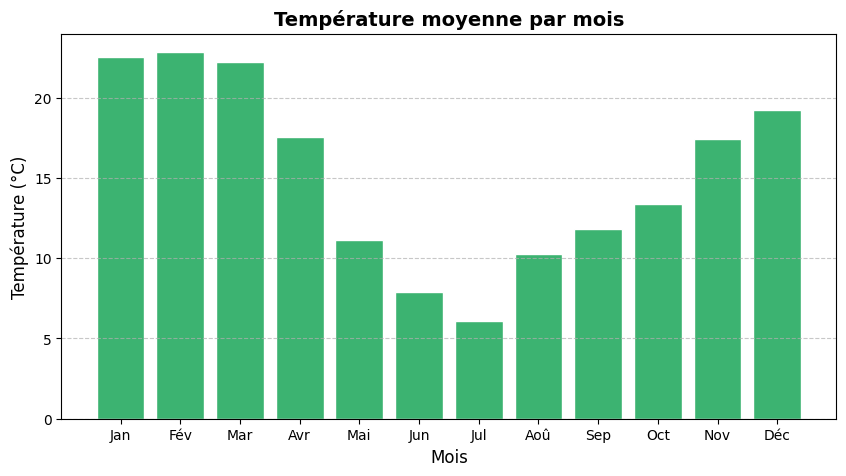

In [46]:
import matplotlib.pyplot as plt

df_temp = x_train["Temperature"]

month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

# Moyenne par mois
monthly = x_train.groupby('month_of_year')['Temperature'].mean().reindex(range(1,13))

plt.figure(figsize=(10,5))
plt.bar(month_labels, monthly.values, color='mediumseagreen', edgecolor='white')
plt.title('Température moyenne par mois', fontsize=14, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Température (°C)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



In [54]:
y_ranks = rankdata(y_train.values) / len(y_train)

y_ranks

array([0.07949648, 0.28694031, 0.8669007 , ..., 0.39624443, 0.42468633,
       0.8669007 ], shape=(6076546,))

In [52]:
y_train.describe()

,invalid_ratio
count,6.076546e+06
mean,5.023941e-01
std,3.683577e-01
min,0.000000e+00
25%,1.944444e-01
50%,4.615385e-01
75%,1.000000e+00
max,1.000000e+00
